<a href="https://colab.research.google.com/github/TaySon-7/APEX-Analytics/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [290]:
# @title {"display-mode":"code"}
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")

print("Path to dataset files:", path)
path = path + '/' + 'student_lifestyle_100k.csv'


Using Colab cache for faster access to the 'student-depression-and-lifestyle-100k-data' dataset.
Path to dataset files: /kaggle/input/student-depression-and-lifestyle-100k-data


Загрузили датасет с Kaggle


In [291]:
print(path)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(path)
df.head()
df.info() # нету пропусков
df.dropna()
df.info()

/kaggle/input/student-depression-and-lifestyle-100k-data/student_lifestyle_100k.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data col

Посмотрели из каких колонок состоит датасет, увидели, что пропусков нет, сейчас будем анализировать числовые колонки


In [292]:

df['Physical_hours'] = df['Physical_Activity'] / 60
df["Day"] = df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours'] + df['Physical_hours']
anomaly = df[(df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours'] + (df['Physical_hours'] / 7)) > 24]
print(anomaly.shape)
df = df[(df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours'] + (df['Physical_hours'] / 7)) <= 24]
df.drop(columns=["Physical_Activity", "Day"], inplace=True)
print(df)

(109, 13)
       Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  \
0            1001   22  Female      Science  3.50             7.3   
1            1002   20    Male  Engineering  2.72             5.5   
2            1003   20    Male      Medical  3.01             5.4   
3            1004   21    Male  Engineering  3.63             8.1   
4            1005   19    Male         Arts  3.14             6.8   
...           ...  ...     ...          ...   ...             ...   
99995      100996   24  Female      Medical  2.02             7.0   
99996      100997   24    Male         Arts  2.33             5.0   
99997      100998   24  Female  Engineering  2.23             6.5   
99998      100999   19    Male  Engineering  3.61             6.1   
99999      101000   24  Female      Medical  2.10             7.9   

       Study_Hours  Social_Media_Hours  Stress_Level  Depression  \
0              3.3                 3.4             5       False   
1              7.2       

Переведена физическая активность в часы и поделена на 7, так как мерика предоставляется за неделю. В сутках всего 24 часа, следовательно сумма учебной, медиа активностей и сна с физической активностью должна быть <= 24. Случаев превышающий количество часов в сутках - 109.

<class 'pandas.core.frame.DataFrame'>
Index: 99891 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 99891 non-null  int64  
 1   Gender              99891 non-null  object 
 2   Department          99891 non-null  object 
 3   CGPA                99891 non-null  float64
 4   Sleep_Duration      99891 non-null  float64
 5   Study_Hours         99891 non-null  float64
 6   Social_Media_Hours  99891 non-null  float64
 7   Stress_Level        99891 non-null  int64  
 8   Depression          99891 non-null  bool   
 9   Physical_hours      99891 non-null  float64
dtypes: bool(1), float64(5), int64(2), object(2)
memory usage: 7.7+ MB
['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Physical_hours']


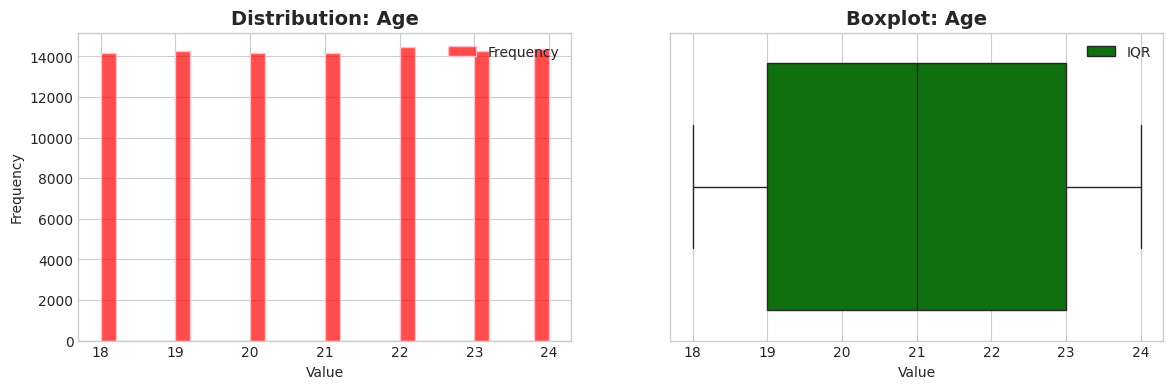

Age:
   |- Distribution: symmetric
   |- median: 21.00
   |- mean: 21.01
   |- Outliers (IQR): 0
--------------------------------------------------------------------------------


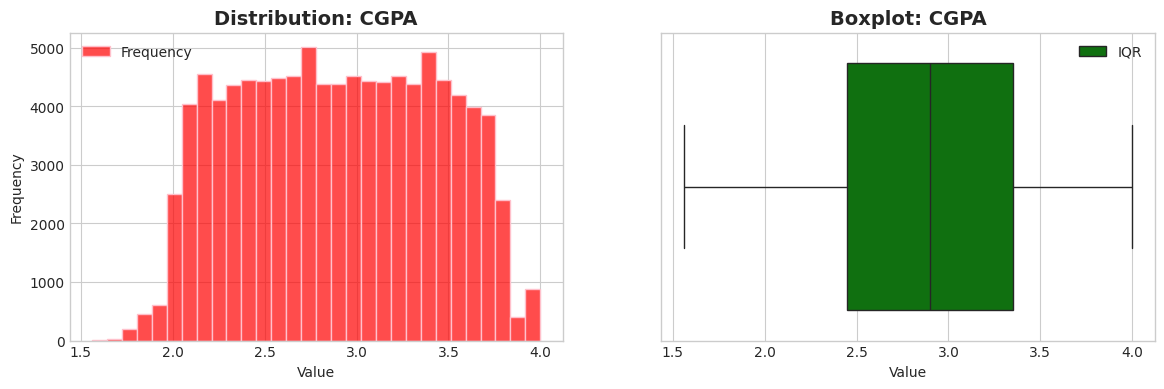

CGPA:
   |- Distribution: symmetric
   |- median: 2.90
   |- mean: 2.90
   |- Outliers (IQR): 0
--------------------------------------------------------------------------------


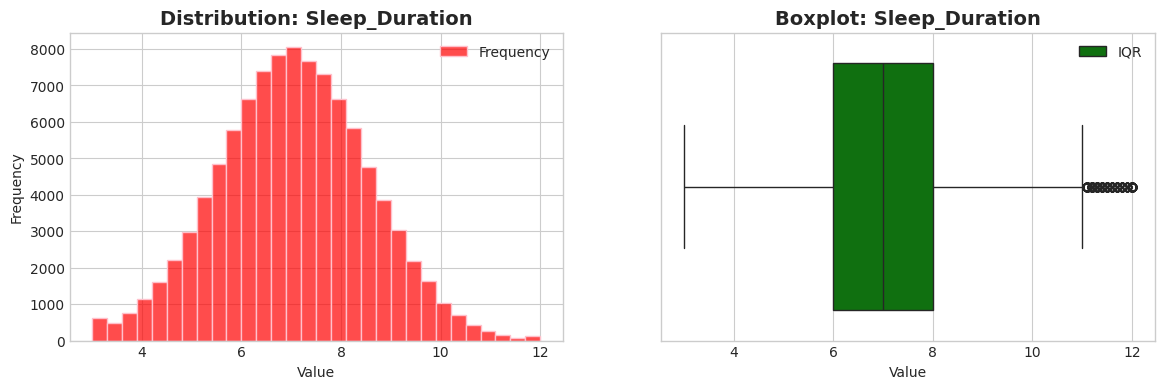

Sleep_Duration:
   |- Distribution: symmetric
   |- median: 7.00
   |- mean: 6.99
   |- Outliers (IQR): 352
--------------------------------------------------------------------------------


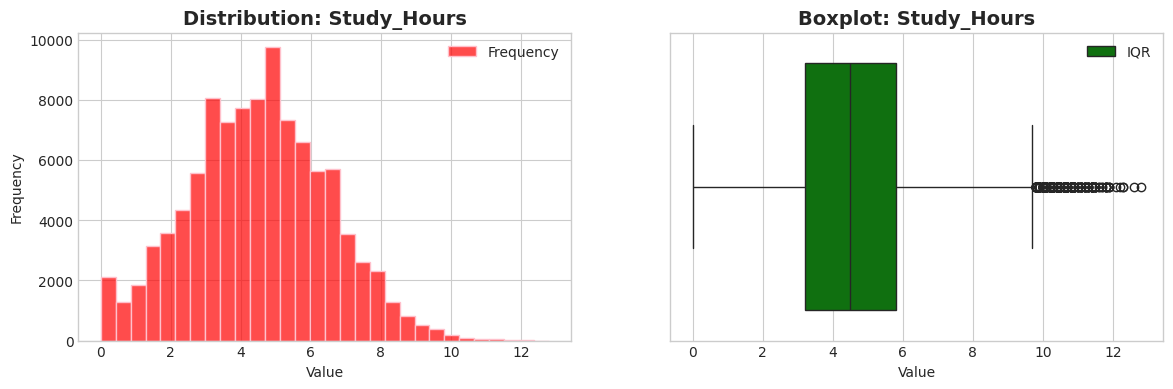

Study_Hours:
   |- Distribution: symmetric
   |- median: 4.50
   |- mean: 4.50
   |- Outliers (IQR): 401
--------------------------------------------------------------------------------


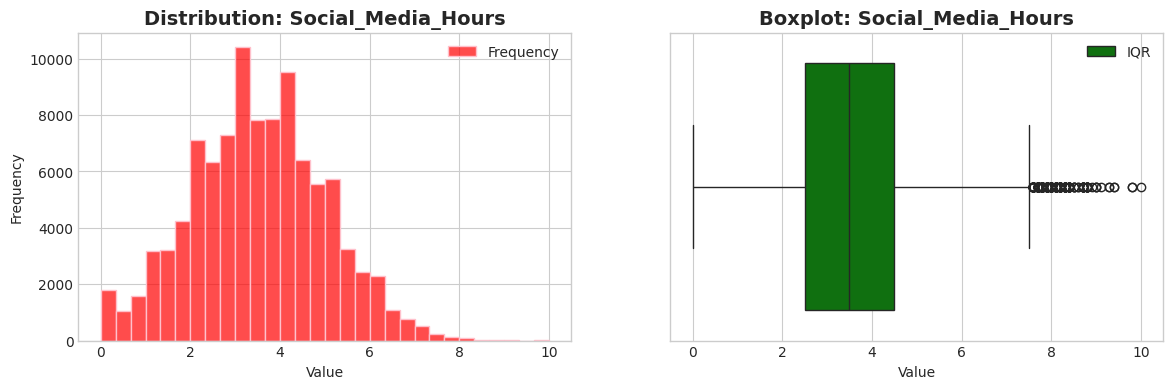

Social_Media_Hours:
   |- Distribution: symmetric
   |- median: 3.50
   |- mean: 3.50
   |- Outliers (IQR): 308
--------------------------------------------------------------------------------


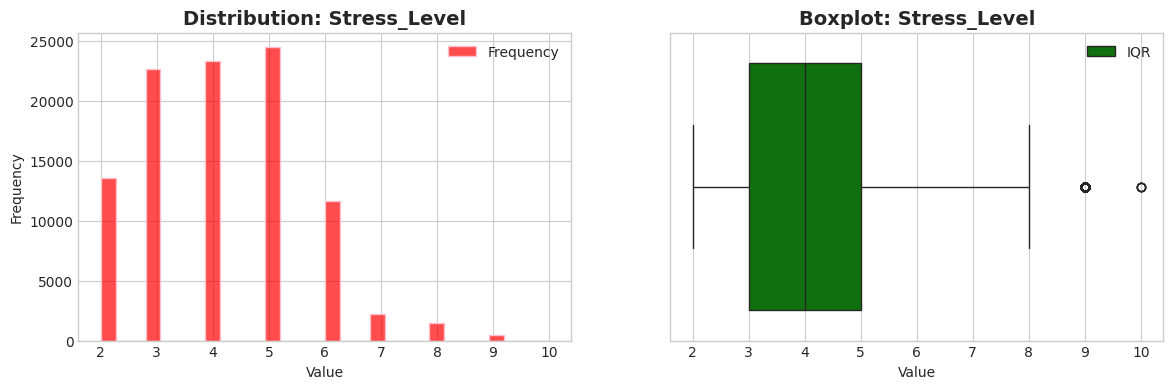

Stress_Level:
   |- Distribution: symmetric
   |- median: 4.00
   |- mean: 4.13
   |- Outliers (IQR): 478
--------------------------------------------------------------------------------


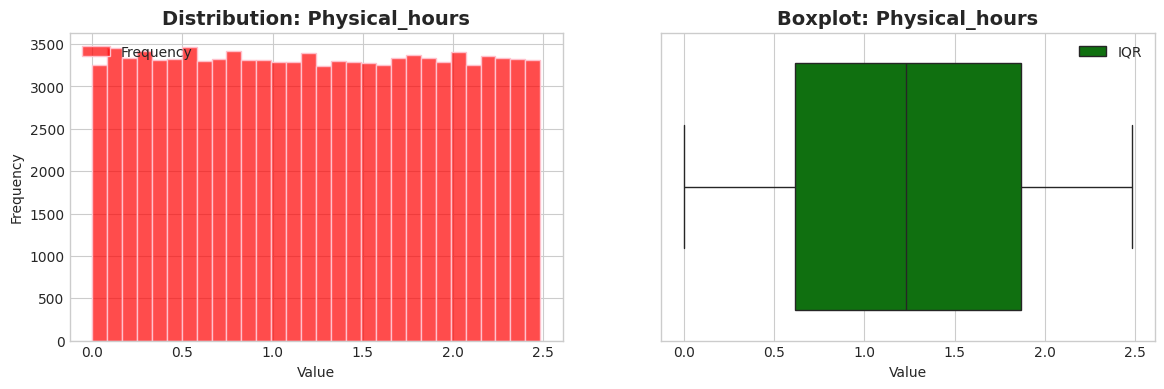

Physical_hours:
   |- Distribution: symmetric
   |- median: 1.23
   |- mean: 1.24
   |- Outliers (IQR): 0
--------------------------------------------------------------------------------


In [293]:
sns.set_style('whitegrid')
sns.set_palette('hls')
plt.rcParams['figure.figsize'] = (16, 5)
df_for_analitics = df.drop(columns="Student_ID") # убрали колонку с id студентов
df_for_analitics.info()
columns = df_for_analitics.select_dtypes(include="number").columns.tolist() # выбираем только числовые признаки
print(columns)
for col in columns:
  fig, axes = plt.subplots(1, 2, figsize=(14, 4))
  # df_aged = df[df['Age'] == 24] просмотрены распределения для разных возрастов
  #df_gender = df[df["Gender"] == 'Female']
  sns.histplot(data=df, x=col, bins=30, kde=False, ax=axes[0],
                     color='red', edgecolor='pink', alpha=0.7)
  axes[0].set_title(f'Distribution: {col}', fontsize=14, fontweight='bold')
  axes[0].set_xlabel('Value')
  axes[0].set_ylabel('Frequency')
  axes[0].legend(['Frequency'])
  sns.boxplot(data=df, x=col, ax=axes[1], color='green')
  axes[1].set_title(f'Boxplot: {col}', fontsize=14, fontweight='bold')
  axes[1].set_xlabel('Value')
  axes[1].legend(['IQR', 'Median', 'Outliers'], loc='best')
  plt.show()
  cold = df[col]
  if len(col) > 0:
            Q1 = cold.quantile(0.25)
            Q3 = cold.quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers_count = ((cold < lower_bound) | (cold > upper_bound)).sum()

            skew = cold.skew()
            if abs(skew) < 0.5:
                skew_text = "symmetric"
            elif skew > 0:
                skew_text = "right-skewed"
            else:
                skew_text = "left-skewed"

            print(f"{col}:")
            print(f"   |- Distribution: {skew_text}")
            print(f"   |- median: {df[col].median():.2f}")
            print(f"   |- mean: {df[col].mean():.2f}")
            print(f"   |- Outliers (IQR): {outliers_count}")
            print("-" * 80)


 Все распределения симметричные, распределение по возрасту можно будет отнести к категориальным признакам, CGPA, продолжительность сна, учебные часы, медиа часы - нормальные рапсределения. Физическая активность - равномерное распределение, уровень стресса можно отнести к категориальным признакам.
 Определено, что возраст, пол не влияет ни на распределение и медиану, среднее признака.

In [294]:
duplicate_rows_df = df[df.duplicated()]
print("Число дублей: ", duplicate_rows_df.shape) # посмотрели, что нет дубликатов

Число дублей:  (0, 11)


<class 'pandas.core.frame.DataFrame'>
Index: 99891 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          99891 non-null  int64  
 1   Age                 99891 non-null  int64  
 2   Gender              99891 non-null  object 
 3   Department          99891 non-null  object 
 4   CGPA                99891 non-null  float64
 5   Sleep_Duration      99891 non-null  float64
 6   Study_Hours         99891 non-null  float64
 7   Social_Media_Hours  99891 non-null  float64
 8   Stress_Level        99891 non-null  int64  
 9   Depression          99891 non-null  bool   
 10  Physical_hours      99891 non-null  float64
dtypes: bool(1), float64(5), int64(3), object(2)
memory usage: 8.5+ MB
Найдено категориальных признаков: 5
Признаки: ['Gender', 'Department', 'Age', 'Stress_Level', 'Depression']



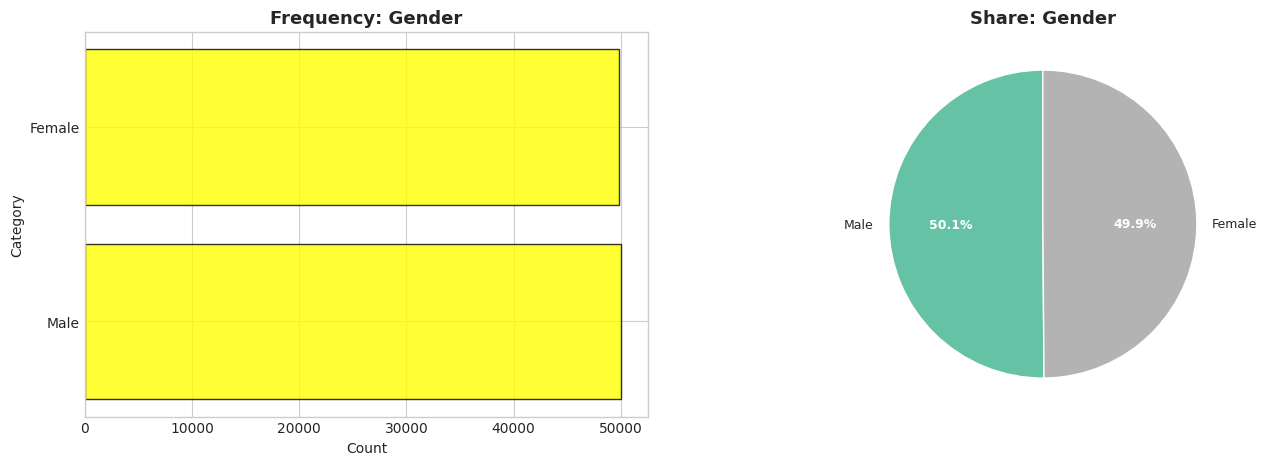

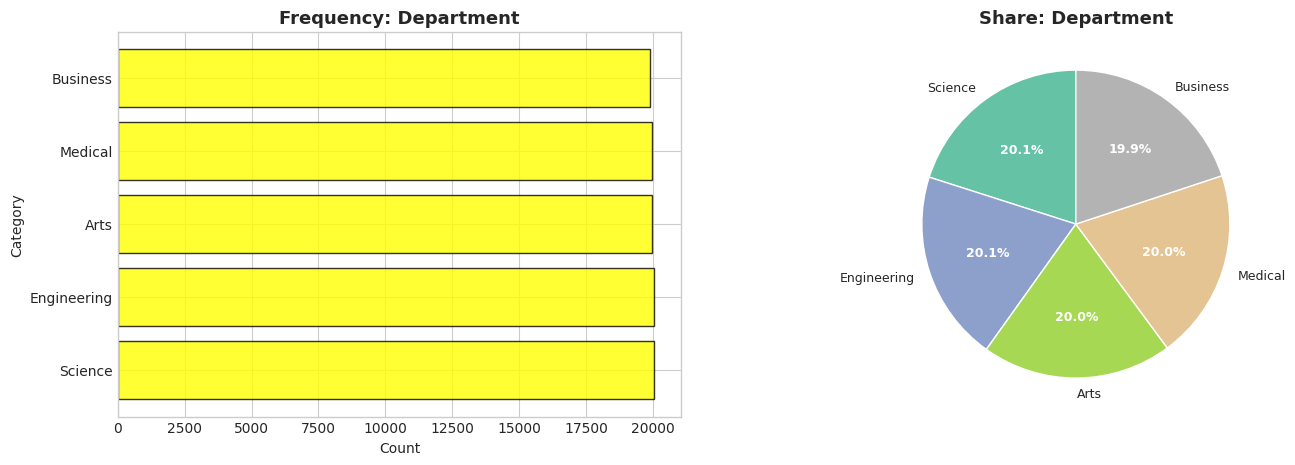

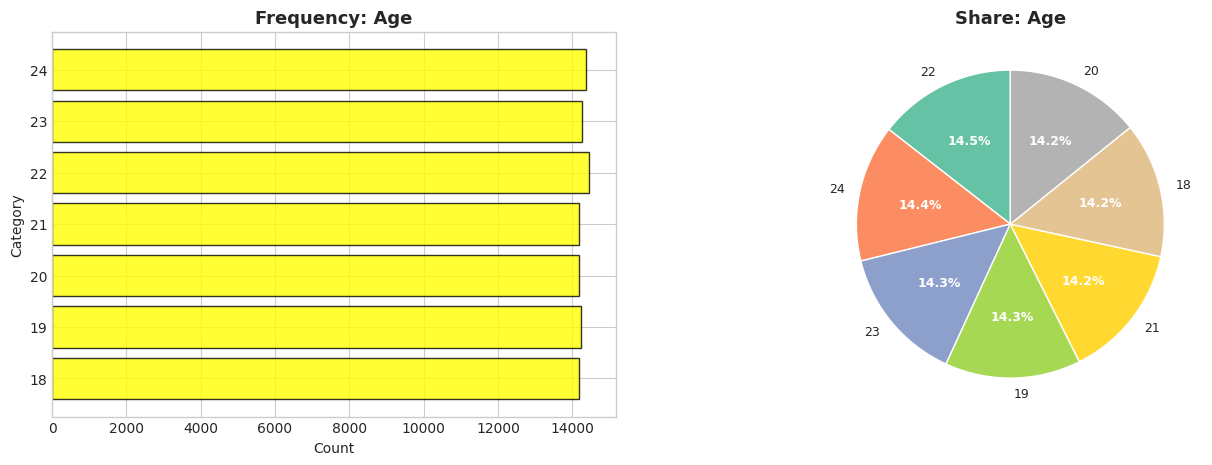

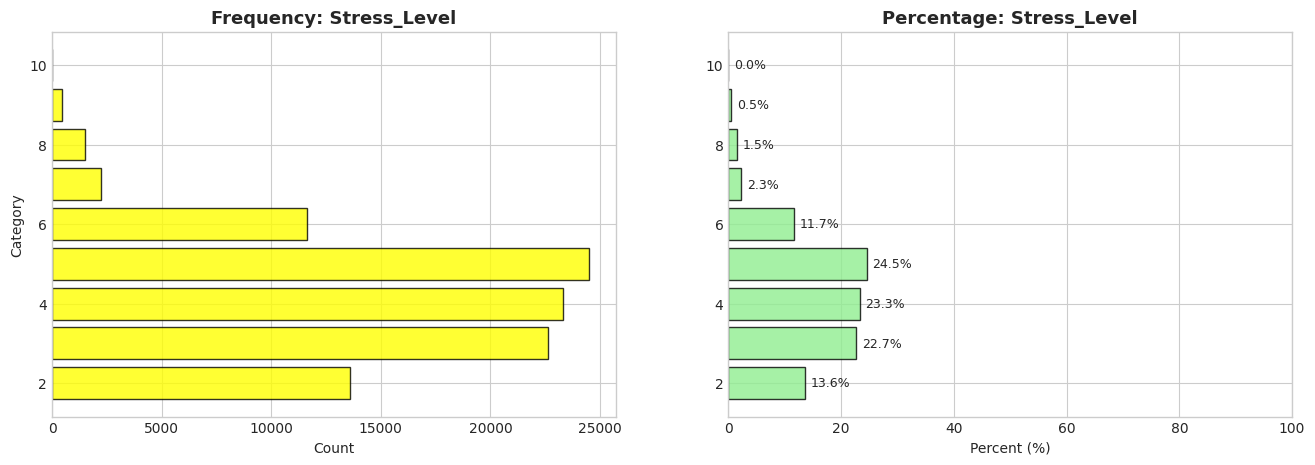

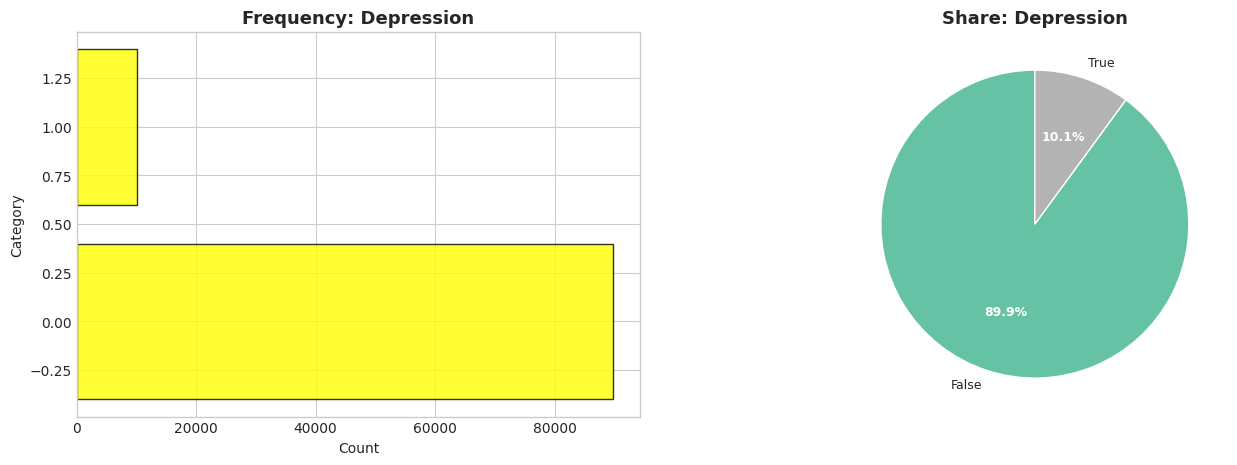

In [295]:
df.info()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_with_few_unique = [
    col for col in df.select_dtypes(include='number').columns
    if df[col].nunique() < 10 and df[col].nunique() > 1 # Некоторые числовые колонки с маленьким разбросом значений будем рассматривать как категориальные
]
# df = df[df["Gender"] == "Female"]
cat_cols.extend(numeric_with_few_unique)
cat_cols.extend(["Depression"])
print(f"Найдено категориальных признаков: {len(cat_cols)}")
print(f"Признаки: {cat_cols}\n")
for cat in cat_cols:
  value_counts = df[cat].value_counts()
  fig, axes = plt.subplots(1, 2, figsize=(16, 5))
  bars = axes[0].barh(value_counts.index[::], value_counts.values[::], # bar график
                        color='yellow', edgecolor='black', alpha=0.8)
  axes[0].set_title(f'Frequency: {cat}', fontsize=13, fontweight='bold')
  axes[0].set_xlabel('Count')
  axes[0].set_ylabel('Category')
  if len(value_counts) <= 8:
        colors = plt.cm.Set2(np.linspace(0, 1, len(value_counts))) # круговая диаграмма
        wedges, texts, autotexts = axes[1].pie(
            value_counts.values,
            labels=value_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=colors,
            textprops={'fontsize': 9}
        )
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
        axes[1].set_title(f'Share: {cat}', fontsize=13, fontweight='bold')
  else:
      percentages = value_counts / value_counts.sum() * 100
      bars = axes[1].barh(percentages.index[::-1], percentages.values[::-1],
                          color='lightgreen', edgecolor='black', alpha=0.8)
      axes[1].set_title(f'Percentage: {cat}', fontsize=13, fontweight='bold')
      axes[1].set_xlabel('Percent (%)')
      axes[1].set_xlim(0, 100)
      for bar in bars:
            width = bar.get_width()
            axes[1].text(width + 1, bar.get_y() + bar.get_height()/2,
                        f'{width:.1f}%', va='center', fontsize=9)
df["Depression"] = df["Depression"].astype(int) # Перевели Depression из bool в int

In [140]:
!pip install feature-engine


In [239]:
from feature_engine.encoding import OneHotEncoder
df_for_analitics.info()
ohe = OneHotEncoder(variables=['Gender', 'Department'], drop_last=True) # переводим в числовые формат категориальные признаки
df_encoded = ohe.fit_transform(df_for_analitics)
df_cor = df_encoded
corr_matrix = df_cor.corr()
corr_matrix.drop_duplicates(inplace=True)
corr_matrix.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 99891 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 99891 non-null  int64  
 1   Gender              99891 non-null  object 
 2   Department          99891 non-null  object 
 3   CGPA                99891 non-null  float64
 4   Sleep_Duration      99891 non-null  float64
 5   Study_Hours         99891 non-null  float64
 6   Social_Media_Hours  99891 non-null  float64
 7   Stress_Level        99891 non-null  int64  
 8   Depression          99891 non-null  bool   
 9   Physical_hours      99891 non-null  float64
dtypes: bool(1), float64(5), int64(2), object(2)
memory usage: 7.7+ MB


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Stress_Level,Depression,Physical_hours,Gender_Female,Department_Science,Department_Engineering,Department_Medical,Department_Arts
Age,1.000000,0.003302,0.001291,-0.003895,-0.000312,0.002922,-0.007645,-0.003614,0.003114,-0.000908,0.000968,-0.002400,0.002853
CGPA,0.003302,1.000000,0.015094,0.099546,-0.088252,-0.012298,-0.179073,0.004948,0.005145,-0.000455,-0.000921,-0.002269,0.004196
Sleep_Duration,0.001291,0.015094,1.000000,-0.001221,-0.006173,-0.282052,-0.057530,0.002856,-0.002526,0.000646,-0.001807,0.002047,0.000664
Study_Hours,-0.003895,0.099546,-0.001221,1.000000,0.001530,0.008432,-0.015972,-0.002450,-0.000650,-0.000615,-0.007156,-0.001876,-0.001454
Social_Media_Hours,-0.000312,-0.088252,-0.006173,0.001530,1.000000,0.002190,0.016730,-0.005371,-0.001390,0.001156,0.001312,0.000776,-0.001497
Stress_Level,0.002922,-0.012298,-0.282052,0.008432,0.002190,1.000000,0.076050,-0.296510,-0.001164,0.004895,-0.001814,-0.002439,-0.001194
Depression,-0.007645,-0.179073,-0.057530,-0.015972,0.016730,0.076050,1.000000,-0.014072,-0.004491,-0.001780,0.000240,-0.001786,0.001358
Physical_hours,-0.003614,0.004948,0.002856,-0.002450,-0.005371,-0.296510,-0.014072,1.000000,-0.004462,-0.005588,0.001056,-0.001922,0.005151
Gender_Female,0.003114,0.005145,-0.002526,-0.000650,-0.001390,-0.001164,-0.004491,-0.004462,1.000000,0.004498,-0.002376,-0.003889,0.001471
Department_Science,-0.000908,-0.000455,0.000646,-0.000615,0.001156,0.004895,-0.001780,-0.005588,0.004498,1.000000,-0.251022,-0.250270,-0.250521


In [240]:
# смотрим макисмальные корреляции признаков
corr_matrix.apply(lambda col: col.abs().nlargest(2).iloc[-1])

,0
Age,0.007645
CGPA,0.179073
Sleep_Duration,0.282052
Study_Hours,0.099546
Social_Media_Hours,0.088252
Stress_Level,0.296510
Depression,0.179073
Physical_hours,0.296510
Gender_Female,0.005145
Department_Science,0.251022


Видно, что больших корреляций нет ни у одного признака. Также корреляиця по возрасту полностью отстутсвует, по области обучения также.

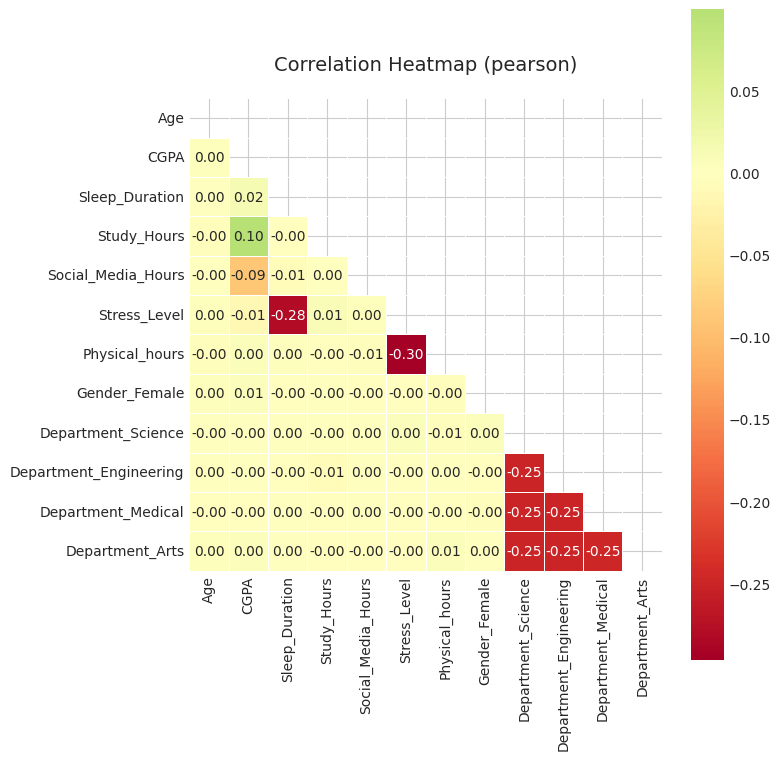

In [241]:
def plot_correlation_heatmap(df, target_col, method, threshold=0.7):
    numeric = df.select_dtypes(include=[np.number])
    corr = numeric.corr(method=method)

    # Heatmap
    plt.figure(figsize=(8, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.5)
    plt.title(f'Correlation Heatmap ({method})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
plot_correlation_heatmap(df_encoded, target_col='CGPA', method='pearson')

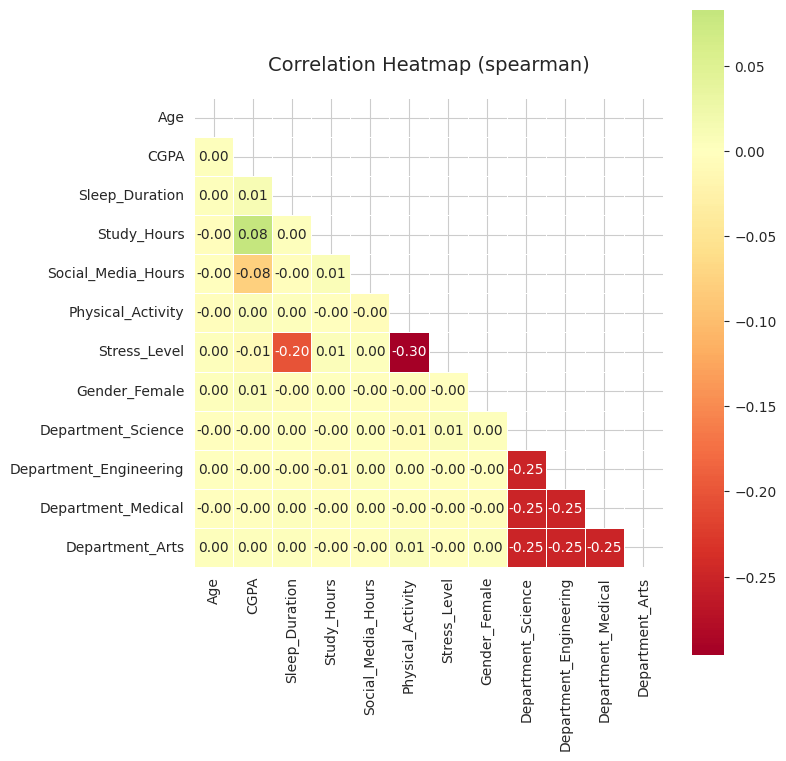

In [162]:
plot_correlation_heatmap(df_encoded, target_col='CGPA', method='spearman')

Единственные очень маленькие корреляции видны меджду увеличением CGPA и увеличиением учебных часов и уменьшение медиа часов, тоже увеличивает CGPA. Также чем выше уровень стресса тем меньше продолжительность сна и физическая активность.

In [320]:
from sklearn.preprocessing import LabelEncoder
from feature_engine.encoding import OneHotEncoder
from sklearn.linear_model import LinearRegression
df_label = df.copy()
le = LabelEncoder()
df_for_linear = df_for_analitics.drop(columns=["Age","Gender", "Department"]) # убираем невлияющие колонки
df_for_linear["Depression"] = df_for_linear["Depression"].astype(int) # Перевели Depression из bool в int
print(df_for_linear.head(10))


   CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  Stress_Level  \
0  3.50             7.3          3.3                 3.4             5   
1  2.72             5.5          7.2                 6.0             2   
2  3.01             5.4          2.3                 1.8             3   
3  3.63             8.1          2.0                 4.6             3   
4  3.14             6.8          2.6                 4.3             6   
5  3.31             6.5          3.5                 4.1             2   
6  2.14             4.4          4.0                 3.1             8   
7  3.27             7.0          3.4                 7.6             4   
8  2.71             4.8          8.6                 0.3             5   
9  3.36             5.7          1.5                 3.7             3   

   Depression  Physical_hours  
0           0        1.900000  
1           0        2.366667  
2           0        2.283333  
3           0        2.166667  
4           0        0.06

 Train:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0499
  MAPE: 16.16%
 Test:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0440
  MAPE: 15.98%


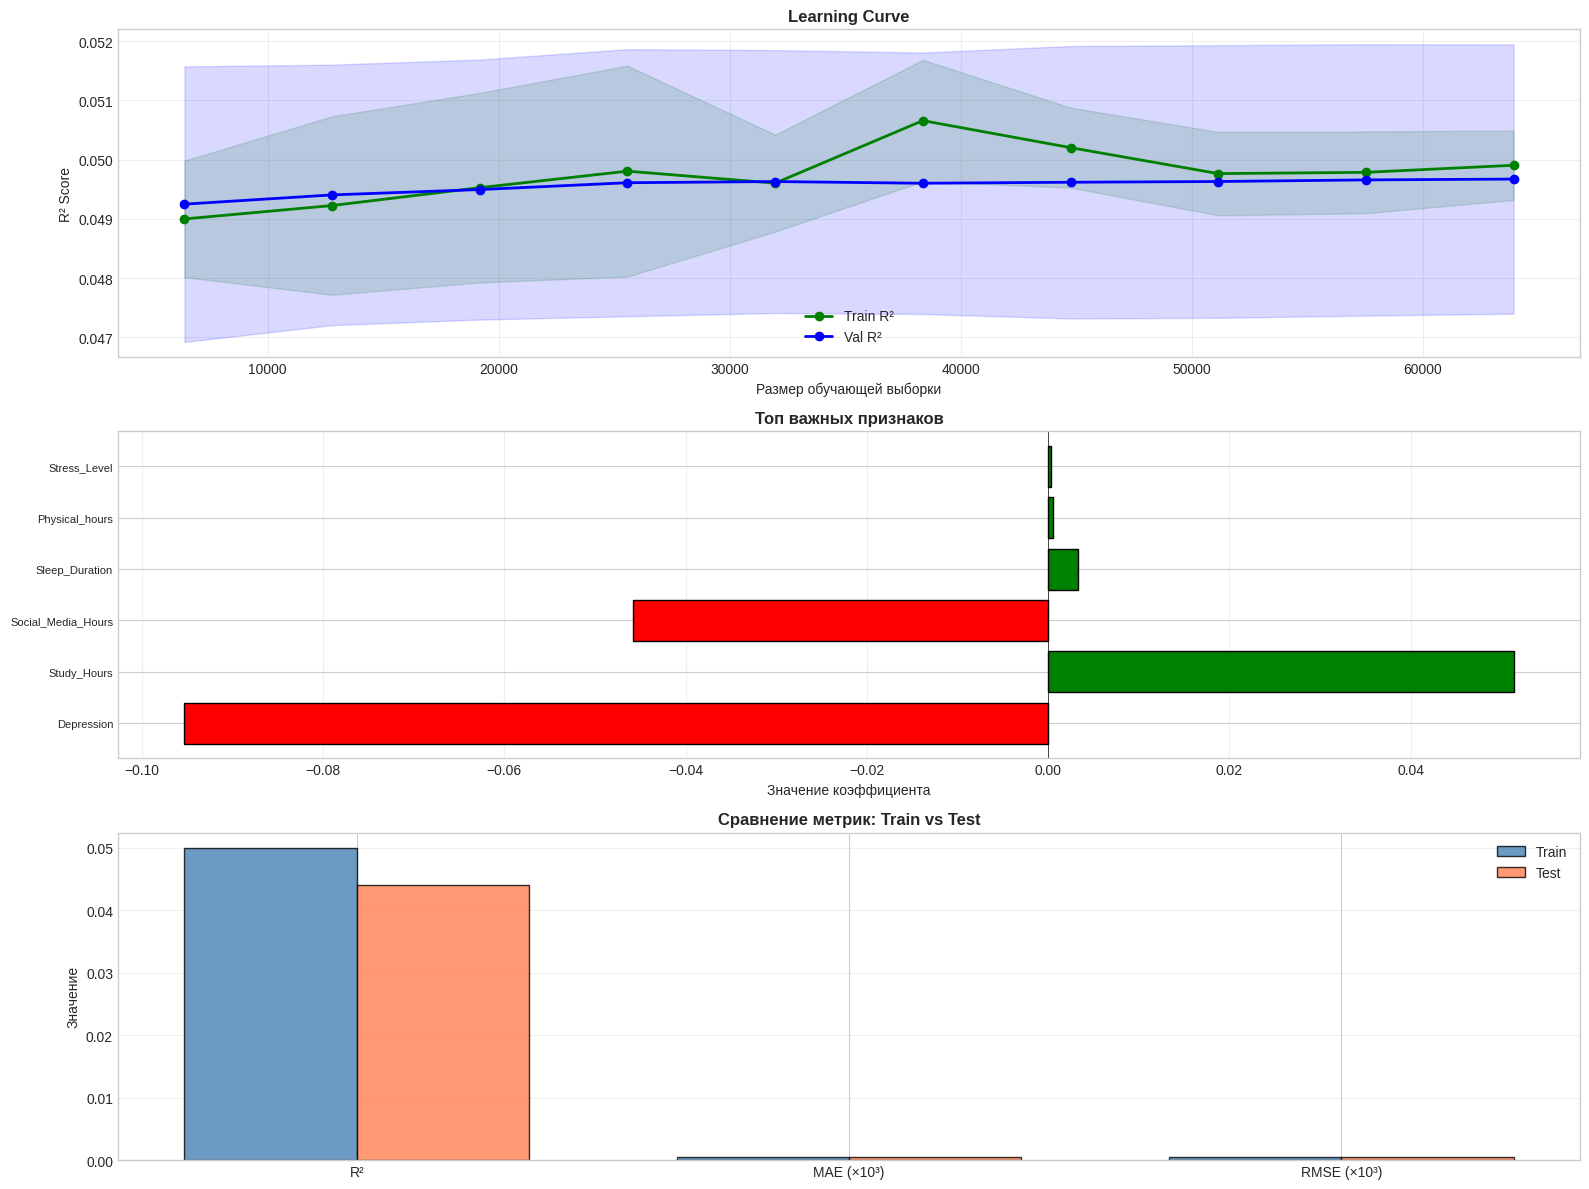

In [257]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
y = df_for_linear['CGPA']
X = df_for_linear.drop(columns=['CGPA'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f" {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Оценка на обеих выборках
train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")
from sklearn.model_selection import learning_curve

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 1, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R² Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.legend()


# влияющие признаки
ax2 = plt.subplot(3, 1, 2)
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax2.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax2.set_xlabel('Значение коэффициента', fontsize=10)
ax2.set_title('Топ важных признаков', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.axvline(x=0, color='black', lw=0.5)
plt.setp(ax2.get_yticklabels(), fontsize=8)

# график для сравнения результатов на train и test
ax3 = plt.subplot(3, 1, 3)
metrics_names = ['R²', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['R2'], train_metrics['MAE']/1000, train_metrics['RMSE']/1000]
test_vals = [test_metrics['R2'], test_metrics['MAE']/1000, test_metrics['RMSE']/1000]

ax3.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax3.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['R²', 'MAE (×10³)', 'RMSE (×10³)'])
ax3.set_ylabel('Значение', fontsize=10)
ax3.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Больше всего на оценку негативно влияет наличие депрессии, следующие топ 2 признака это учебные и медиа часы. R2 метрика близка к нулю,что говорит о усреднение данных.

In [321]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import SGDClassifier
df_logistic = df_for_analitics
y = df_logistic["Depression"]
X = df_for_linear.drop(columns=['Depression'])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SGDClassifier(
    loss='log_loss',        # лог-лосс → логистическая регрессия
    penalty='l2',           # L2-регуляризация (как в LogisticRegression)        # сила регуляризации (аналог 1/C)
    learning_rate='constant',  # режим learning rate
    eta0=0.01,              # НАЧАЛЬНЫЙ learning rate
    max_iter=100,          # количество эпох
    random_state=42
)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)
def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

# Оценка на обеих выборках
train_metrics = evaluate_classification(y_train, y_train_pred, dataset_name="Train")
print(y_test_proba.shape)
test_metrics = evaluate_classification(y_test, y_test_pred, y_proba=y_test_proba[:,1], dataset_name="Test")


📊 Метрики для Train:
  Accuracy:  0.2462
  Precision: 0.1108
  Recall:    0.9232
  F1-Score:  0.1978
(19979, 2)

📊 Метрики для Test:
  Accuracy:  0.2414
  Precision: 0.1078
  Recall:    0.9008
  F1-Score:  0.1925
  AUC-ROC:   0.6686


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


In [322]:

filtered_df_false = df_for_linear[df_for_linear['Depression'] == 0]
sample_10_percent = filtered_df_false.sample(frac=0.11)
filteres_df_true = df_for_linear[df_for_linear['Depression'] == 1]
df_merged = pd.concat([sample_10_percent, filteres_df_true], ignore_index=True)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19933 entries, 0 to 19932
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CGPA                19933 non-null  float64
 1   Sleep_Duration      19933 non-null  float64
 2   Study_Hours         19933 non-null  float64
 3   Social_Media_Hours  19933 non-null  float64
 4   Stress_Level        19933 non-null  int64  
 5   Depression          19933 non-null  int64  
 6   Physical_hours      19933 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.1 MB
      CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  Stress_Level  \
0     3.66             8.7          3.6                 2.8             5   
1     3.56             7.6          2.2                 3.1             5   
2     3.04             6.1          4.1                 3.3             5   
3     2.70             7.4          1.1                 2.9             2   
4     2.09      

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_6379/2668791782.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no arg

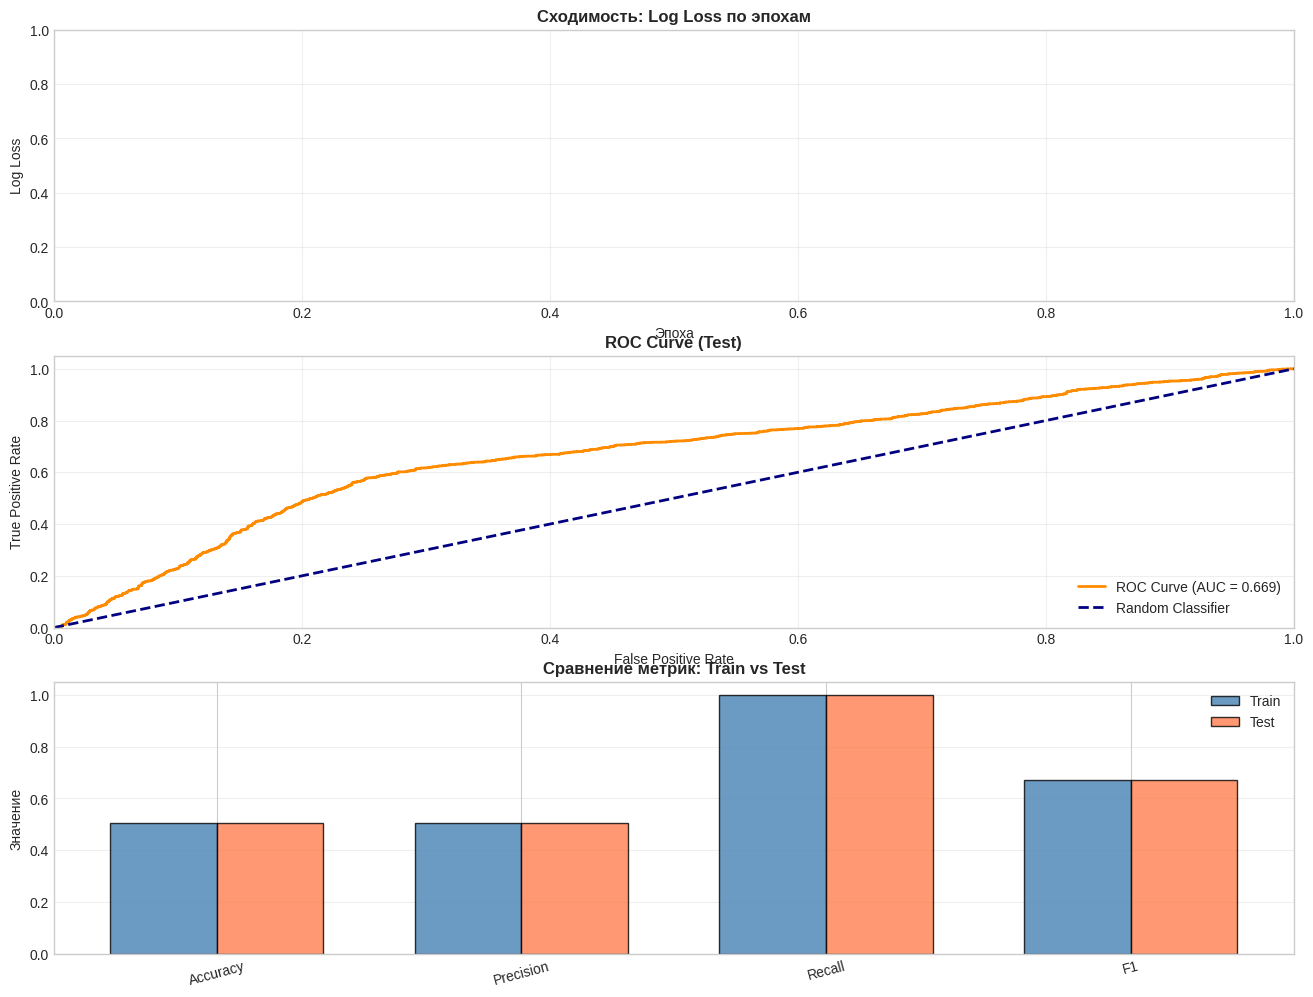

In [328]:
y = df_merged["Depression"]
X = df_merged.drop(columns=['Depression'])
df_merged.info()
print(df_merged[df_merged["Depression"] == False])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
epochs = 9
model = SGDClassifier(
    loss='log_loss',        # лог-лосс → логистическая регрессия
    penalty='l2',           # L2-регуляризация (как в LogisticRegression)        # сила регуляризации (аналог 1/C)
    learning_rate='constant',  # режим learning rate
    eta0=0.01,              # НАЧАЛЬНЫЙ learning rate
    max_iter=epochs,          # количество эпох
    random_state=42
)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)
def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

# Оценка на обеих выборках
train_metrics = evaluate_classification(y_train, y_train_pred, dataset_name="Train")
test_metrics = evaluate_classification(y_test, y_test_pred, y_proba=y_test_proba[:,1], dataset_name="Test")

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

# --- 5.1 Loss History (Log Loss по эпохам) ---
ax1 = plt.subplot(3, 1, 1)

ax1.set_xlabel('Эпоха', fontsize=10)
ax1.set_ylabel('Log Loss', fontsize=10)
ax1.set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 1, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba[:, 1])
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=10)
ax3.set_ylabel('True Positive Rate', fontsize=10)
ax3.set_title('ROC Curve (Test)', fontsize=12, fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 1, 3)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

ax5.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax5.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(metrics_names, rotation=15)
ax5.set_ylabel('Значение', fontsize=10)
ax5.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 1.05)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')